# CRISP-DM — Fase de Modelamiento y Evaluación **v2**
## Predicción de Score de Riesgo Trimestral

Los modelos fueron seleccionados a partir de la síntesis de artículos de investigación (*Análisis de Modelos de IA para la Predicción de Riesgo*), priorizando aquellos con mejor desempeño reportado por categoría.

### Familias de modelos incluidas:
| Familia | Modelos | Referencia principal |
|---|---|---|
|  **Ensamble / Boosting** | XGBoost, LightGBM, GBM, RF | Alanis 2023, Woloszko 2020, Steinberg 2023 |
|  **Regularización lineal** | Ridge, Lasso, ElasticNet | Yan 2025, Chi 2025 (benchmarks) |
|  **Redes profundas (DNN)** | MLP con BatchNorm + Dropout | Woloszko 2020, Steinberg 2023 |
|  **Redes recurrentes** | LSTM, GRU, Bi-LSTM | Tenorio 2025, Zogaan 2025, Mohamed 2019 |
| 🕸️ **Grafos (GNN)** | GCN, GAT | Das 2023, Yang 2020 |

### Variables objetivo:
| Variable | Tipo | Tarea | Mejor desempeño en literatura |
|---|---|---|---|
| **risk_score_next** | Continua [0,1] | **Regresión** | XGBoost / LightGBM / LSTM |
| **target_distress_next** | Binaria {0,1} | **Clasificación binaria** | XGBoost / Bi-LSTM / GCN |
| **target_class_next** | Multiclase {0,1,2} | **Clasificación multiclase** | XGBoost / GAT / GRU |

---

## 0. Instalación de Dependencias y Configuración Global

In [4]:
# ── Instalación de dependencias opcionales ──────────────────────────────────
import subprocess, sys

def _install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

for pkg, name in [('xgboost','xgboost'), ('lightgbm','lightgbm'),
                  ('torch','torch'), ('torch_geometric','torch_geometric')]:
    try:
        __import__(pkg)
        print(f'* {name} OK')
    except ImportError:
        _install(name); print(f' {name} instalado')

# ── Librerías base ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Preprocesamiento ────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# ── Modelos sklearn ─────────────────────────────────────────────────────────
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                              RandomForestClassifier, GradientBoostingClassifier)

# ── Boosting ────────────────────────────────────────────────────────────────
import xgboost as xgb
import lightgbm as lgb

# ── PyTorch ─────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ── PyTorch Geometric (GNN) ──────────────────────────────────────────────────
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool
from torch_geometric.loader import DataLoader as PyGLoader

# ── Métricas ────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error,
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)

# ── Configuración global ────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
RANDOM_STATE = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

print(f'\n Librerías importadas correctamente.')
print(f'   XGBoost {xgb.__version__}  |  LightGBM {lgb.__version__}  |  PyTorch device: {DEVICE}')

* xgboost OK
* lightgbm OK
* torch OK
* torch_geometric OK

 Librerías importadas correctamente.
   XGBoost 3.2.0  |  LightGBM 4.6.0  |  PyTorch device: cpu


## 1. Carga del Dataset

In [5]:
# ── Ruta del dataset ────────────────────────────────────────────────────────
DATA_PATH = 'training_dataset_riesgo_trimestral_v1.csv'

df = pd.read_csv(DATA_PATH)

print(f' Dataset cargado: {df.shape[0]:,} registros × {df.shape[1]} columnas')
print()
df.head(10)

 Dataset cargado: 85,924 registros × 31 columnas



,adsh,cik,name,sic,form,period,filed,fy,fp,periodo,...,flag_liquidez_critica,flag_fco_negativo,n_alertas,flag_deterioro,fp_orden.1,risk_score_0_1.1,altman_zscore,target_distress_next,target_class_next,risk_score_next
0,0001144204-18-053676,2034,ACETO CORP,5122.0,10-Q/A,20180331.0,1970-01-01 00:00:00.020181012,2018,Q3,2018-Q3,...,0,0,2,NaN,3,NaN,NaN,1,2,0.787804
1,0001144204-18-051414,2034,ACETO CORP,5122.0,10-K,20180630.0,1970-01-01 00:00:00.020180928,2018,FY,2018-FY,...,0,0,2,NaN,4,0.787804,-0.081741,1,1,0.632928
2,0001144204-18-058572,2034,ACETO CORP,5122.0,10-Q,20180930.0,1970-01-01 00:00:00.020181109,2019,Q1,2019-Q1,...,0,1,3,0.0,1,0.632928,0.685202,1,2,0.680331
3,0001026608-18-000010,2098,ACME UNITED CORP,3420.0,10-K,20171231.0,1970-01-01 00:00:00.020180315,2017,FY,2017-FY,...,0,0,0,NaN,4,NaN,NaN,0,0,0.225953
4,0001026608-18-000019,2098,ACME UNITED CORP,3420.0,10-Q,20180331.0,1970-01-01 00:00:00.020180510,2018,Q1,2018-Q1,...,0,1,1,NaN,1,0.225953,2.461307,0,0,0.216521
5,0001026608-18-000027,2098,ACME UNITED CORP,3420.0,10-Q,20180630.0,1970-01-01 00:00:00.020180809,2018,Q2,2018-Q2,...,0,1,1,0.0,2,0.216521,2.516054,0,0,0.206981
6,0001026608-18-000047,2098,ACME UNITED CORP,3420.0,10-Q,20180930.0,1970-01-01 00:00:00.020181109,2018,Q3,2018-Q3,...,0,1,1,0.0,3,0.206981,2.573223,0,0,0.201576
7,0001026608-19-000011,2098,ACME UNITED CORP,3420.0,10-K,20181231.0,1970-01-01 00:00:00.020190315,2018,FY,2018-FY,...,0,0,0,0.0,4,0.201576,2.606472,0,0,0.228030
8,0001026608-19-000026,2098,ACME UNITED CORP,3420.0,10-Q,20190331.0,1970-01-01 00:00:00.020190509,2019,Q1,2019-Q1,...,0,1,1,1.0,1,0.228030,2.449471,0,0,0.200890
9,0001026608-19-000033,2098,ACME UNITED CORP,3420.0,10-Q,20190630.0,1970-01-01 00:00:00.020190807,2019,Q2,2019-Q2,...,0,0,0,0.0,2,0.200890,2.610742,0,0,0.191841


## 2. Definición de Features y Variables Objetivo

In [6]:
# ── Columnas de identificación (excluidas del modelo) ───────────────────────
ID_COLS = [
    'adsh', 'cik', 'name', 'sic', 'form', 'period',
    'filed', 'fy', 'fp', 'periodo', 'fp_orden', 'fp_orden.1',
    'countryba', 'stprba', 'risk_score_0_1.1', 'altman_zscore',
    'risk_score_0_1', 'risk_score_prev'
]

# ── Variables objetivo ──────────────────────────────────────────────────────
TARGET_REG    = 'risk_score_next'        # Regresión
TARGET_BIN    = 'target_distress_next'   # Clasificación binaria
TARGET_MULTI  = 'target_class_next'      # Clasificación multiclase

TARGET_COLS = [TARGET_REG, TARGET_BIN, TARGET_MULTI]

# ── Features ────────────────────────────────────────────────────────────────
FEATURE_COLS = [c for c in df.columns if c not in ID_COLS + TARGET_COLS]

print(' Features utilizados:')
for f in FEATURE_COLS:
    nulls = df[f].isnull().sum()
    print(f'   • {f:<35} dtype={str(df[f].dtype):<10} nulls={nulls:,}')

print(f'\nTargets: {TARGET_COLS}')

 Features utilizados:
   • delta_risk_score                    dtype=float64    nulls=11,107
   • delta_risk_score_prev               dtype=float64    nulls=15,937
   • aceleracion_riesgo                  dtype=float64    nulls=16,616
   • flag_patrimonio_negativo            dtype=int64      nulls=0
   • flag_perdida_neta                   dtype=int64      nulls=0
   • flag_deficit_acumulado              dtype=int64      nulls=0
   • flag_liquidez_critica               dtype=int64      nulls=0
   • flag_fco_negativo                   dtype=int64      nulls=0
   • n_alertas                           dtype=int64      nulls=0
   • flag_deterioro                      dtype=float64    nulls=11,107

Targets: ['risk_score_next', 'target_distress_next', 'target_class_next']


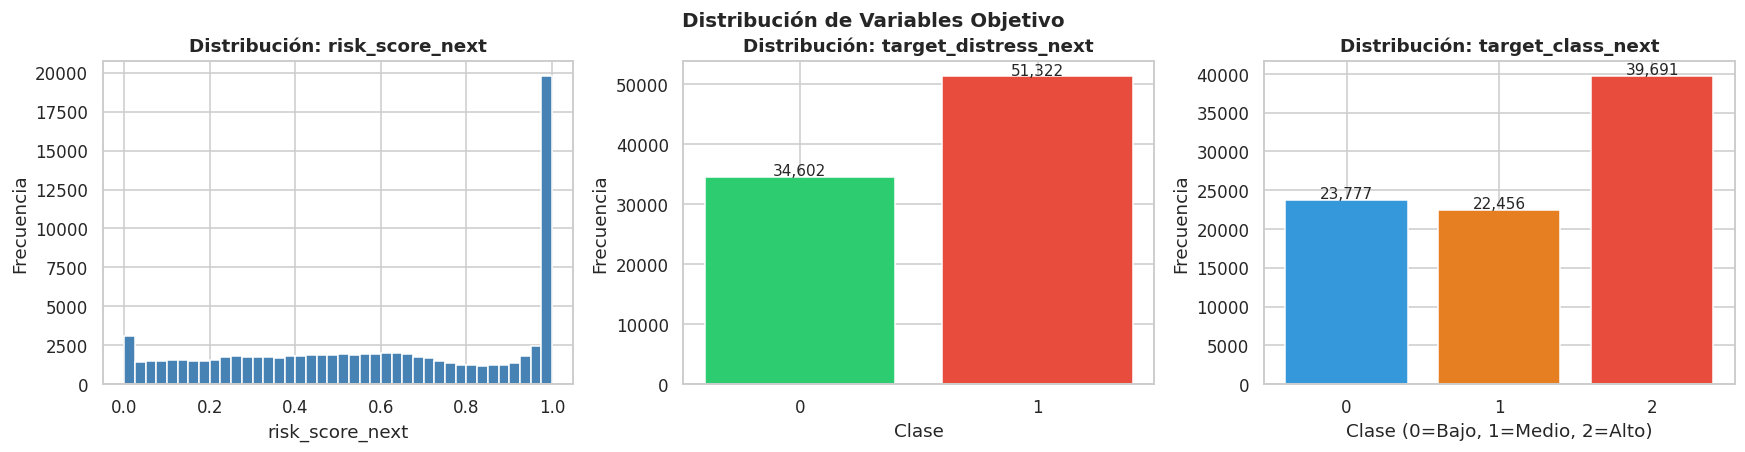

In [7]:
# ── Resumen de distribución de targets ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Regresión
axes[0].hist(df[TARGET_REG].dropna(), bins=40, color='steelblue', edgecolor='white')
axes[0].set_title(f'Distribución: {TARGET_REG}', fontweight='bold')
axes[0].set_xlabel('risk_score_next')
axes[0].set_ylabel('Frecuencia')

# Binaria
vc_bin = df[TARGET_BIN].value_counts().sort_index()
axes[1].bar(vc_bin.index.astype(str), vc_bin.values, color=['#2ecc71','#e74c3c'])
axes[1].set_title(f'Distribución: {TARGET_BIN}', fontweight='bold')
axes[1].set_xlabel('Clase')
axes[1].set_ylabel('Frecuencia')
for i, v in enumerate(vc_bin.values):
    axes[1].text(i, v + 200, f'{v:,}', ha='center', fontsize=10)

# Multiclase
vc_mc = df[TARGET_MULTI].value_counts().sort_index()
colors_mc = ['#3498db','#e67e22','#e74c3c']
axes[2].bar(vc_mc.index.astype(str), vc_mc.values, color=colors_mc)
axes[2].set_title(f'Distribución: {TARGET_MULTI}', fontweight='bold')
axes[2].set_xlabel('Clase (0=Bajo, 1=Medio, 2=Alto)')
axes[2].set_ylabel('Frecuencia')
for i, v in enumerate(vc_mc.values):
    axes[2].text(i, v + 200, f'{v:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.suptitle('Distribución de Variables Objetivo', fontsize=13, fontweight='bold', y=1.02)
plt.show()

## 3. Preparación de Datos para Modelamiento

In [8]:
X = df[FEATURE_COLS].copy()

# ── Pipeline de preprocesamiento (imputación + escalado) ────────────────────
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

X_processed = preprocessor.fit_transform(X)
X_processed = pd.DataFrame(X_processed, columns=FEATURE_COLS)

print(f'✅ Features procesados: {X_processed.shape}')
print(f'   Valores nulos tras imputación: {X_processed.isnull().sum().sum()}')

✅ Features procesados: (85924, 10)
   Valores nulos tras imputación: 0


In [9]:
# ── Splits por variable objetivo ────────────────────────────────────────────
TEST_SIZE = 0.20

# Regresión
y_reg = df[TARGET_REG]
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_processed, y_reg, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

# Binaria
y_bin = df[TARGET_BIN]
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_processed, y_bin, test_size=TEST_SIZE,
    stratify=y_bin, random_state=RANDOM_STATE
)

# Multiclase
y_mc = df[TARGET_MULTI]
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_processed, y_mc, test_size=TEST_SIZE,
    stratify=y_mc, random_state=RANDOM_STATE
)

print('Tamaños de conjuntos:')
print(f'   Regresión   → Train: {X_train_r.shape[0]:,} | Test: {X_test_r.shape[0]:,}')
print(f'   Binaria     → Train: {X_train_b.shape[0]:,} | Test: {X_test_b.shape[0]:,}')
print(f'   Multiclase  → Train: {X_train_m.shape[0]:,} | Test: {X_test_m.shape[0]:,}')

N_FEAT    = X_processed.shape[1]   # número de features — usado por las redes neuronales
N_CLASSES = 3                       # clases multiclase: Bajo / Medio / Alto

Tamaños de conjuntos:
   Regresión   → Train: 68,739 | Test: 17,185
   Binaria     → Train: 68,739 | Test: 17,185
   Multiclase  → Train: 68,739 | Test: 17,185


---
## 4. Arquitecturas de Redes Neuronales (PyTorch)

Se definen **DNN, LSTM, GRU, Bi-LSTM** (redes secuenciales) y **GCN, GAT** (redes de grafos). Cada arquitectura es reutilizable para regresión, clasificación binaria y multiclase ajustando únicamente la capa de salida.

In [10]:
# ════════════════════════════════════════════════════════════════════════════
# DNN — Red Neuronal Profunda (MLP con BatchNorm y Dropout)
# Ref: Woloszko (2020), Steinberg et al. (2023)
# ════════════════════════════════════════════════════════════════════════════
class DNNModel(nn.Module):
    def __init__(self, in_features, out_features, hidden_dims=(256, 128, 64), dropout=0.3):
        super().__init__()
        layers, prev = [], in_features
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        self.backbone = nn.Sequential(*layers)
        self.head = nn.Linear(prev, out_features)

    def forward(self, x):
        return self.head(self.backbone(x))


# ════════════════════════════════════════════════════════════════════════════
# LSTM — Long Short-Term Memory
# Ref: Zogaan et al. (2025), Tenorio et al. (2025), Chen et al. (2024)
# ════════════════════════════════════════════════════════════════════════════
class LSTMModel(nn.Module):
    def __init__(self, in_features, out_features, hidden=128, num_layers=2,
                 dropout=0.3, bidirectional=False):
        super().__init__()
        self.lstm = nn.LSTM(in_features, hidden, num_layers=num_layers,
                            dropout=dropout, batch_first=True, bidirectional=bidirectional)
        factor = 2 if bidirectional else 1
        self.head = nn.Linear(hidden * factor, out_features)

    def forward(self, x):
        if x.dim() == 2: x = x.unsqueeze(1)   # (batch, seq=1, features)
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])         # último time-step


# ════════════════════════════════════════════════════════════════════════════
# GRU — Gated Recurrent Unit (variante ligera del LSTM)
# Ref: Zogaan et al. (2025), Chen et al. (2024)
# ════════════════════════════════════════════════════════════════════════════
class GRUModel(nn.Module):
    def __init__(self, in_features, out_features, hidden=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.gru = nn.GRU(in_features, hidden, num_layers=num_layers,
                          dropout=dropout, batch_first=True)
        self.head = nn.Linear(hidden, out_features)

    def forward(self, x):
        if x.dim() == 2: x = x.unsqueeze(1)
        out, _ = self.gru(x)
        return self.head(out[:, -1, :])


# ════════════════════════════════════════════════════════════════════════════
# GCN — Graph Convolutional Network
# Ref: Das et al. (2023) — GCN/GraphSAGE superó modelos flat en datos SEC
# ════════════════════════════════════════════════════════════════════════════
class GCNModel(nn.Module):
    def __init__(self, in_features, out_features, hidden=128, dropout=0.3):
        super().__init__()
        self.conv1 = GCNConv(in_features, hidden)
        self.conv2 = GCNConv(hidden, hidden // 2)
        self.head  = nn.Linear(hidden // 2, out_features)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x, edge_index, batch):
        x = torch.relu(self.conv1(x, edge_index))
        x = self.drop(x)
        x = torch.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch)  # grafo → embedding por muestra
        return self.head(x)


# ════════════════════════════════════════════════════════════════════════════
# GAT — Graph Attention Network
# Ref: Yang et al. (2020) — ST-GNN/GAT para riesgo de PYMEs en redes dinámicas
# ════════════════════════════════════════════════════════════════════════════
class GATModel(nn.Module):
    def __init__(self, in_features, out_features, hidden=64, heads=4, dropout=0.3):
        super().__init__()
        self.conv1 = GATConv(in_features, hidden, heads=heads, dropout=dropout)
        self.conv2 = GATConv(hidden * heads, hidden, heads=1, concat=False, dropout=dropout)
        self.head  = nn.Linear(hidden, out_features)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x, edge_index, batch):
        x = torch.relu(self.conv1(x, edge_index))
        x = self.drop(x)
        x = torch.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.head(x)


print('Arquitecturas definidas: DNN | LSTM | GRU | Bi-LSTM | GCN | GAT')

Arquitecturas definidas: DNN | LSTM | GRU | Bi-LSTM | GCN | GAT


In [11]:
# ── Funciones de entrenamiento e inferencia ──────────────────────────────────

def _to_tensor(arr):
    v = arr.values if hasattr(arr, 'values') else arr
    return torch.tensor(v, dtype=torch.float32)


def train_nn(model, X_tr, y_tr, task='reg', epochs=40, batch_size=512, lr=1e-3, patience=5):
    """Entrena DNN / LSTM / GRU con early-stopping sobre loss de entrenamiento."""
    X_t = _to_tensor(X_tr)
    y_t = _to_tensor(y_tr)
    if task == 'bin':  y_t = y_t.float()
    if task == 'multi': y_t = y_t.long()

    loss_fn = {'reg': nn.MSELoss(), 'bin': nn.BCEWithLogitsLoss(),
               'multi': nn.CrossEntropyLoss()}[task]

    loader = DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=True)
    model  = model.to(DEVICE)
    opt    = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sched  = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=2, factor=0.5)

    best_loss, wait = float('inf'), 0
    model.train()
    for _ in range(epochs):
        ep_loss = 0
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            out = model(xb)
            loss = loss_fn(out.squeeze(-1) if task != 'multi' else out, yb)
            loss.backward(); opt.step()
            ep_loss += loss.item()
        ep_loss /= len(loader)
        sched.step(ep_loss)
        if ep_loss < best_loss - 1e-5: best_loss, wait = ep_loss, 0
        else:
            wait += 1
            if wait >= patience: break
    return model


def predict_nn(model, X_te, task='reg', batch_size=1024):
    """Inferencia en batches; devuelve numpy array de logits o probs."""
    loader = DataLoader(TensorDataset(_to_tensor(X_te)), batch_size=batch_size)
    model.eval(); preds = []
    with torch.no_grad():
        for (xb,) in loader:
            preds.append(model(xb.to(DEVICE)).cpu())
    return torch.cat(preds).numpy()


def build_knn_graphs(X_arr, y_arr, k=5):
    """Construye grafos k-NN para GCN/GAT. Un grafo por muestra."""
    from sklearn.neighbors import NearestNeighbors
    nbrs = NearestNeighbors(n_neighbors=k + 1).fit(X_arr)
    _, indices = nbrs.kneighbors(X_arr)
    graphs = []
    for i in range(len(X_arr)):
        node_idx = indices[i]
        x_nodes  = torch.tensor(X_arr[node_idx], dtype=torch.float32)
        src = torch.zeros(k, dtype=torch.long)
        dst = torch.arange(1, k + 1, dtype=torch.long)
        edge_index = torch.stack([torch.cat([src, dst]), torch.cat([dst, src])])
        graphs.append(Data(x=x_nodes, edge_index=edge_index,
                           y=torch.tensor([y_arr[i]], dtype=torch.float32)))
    return graphs


def train_gnn(model, graphs_tr, task='reg', epochs=15, batch_size=256, lr=1e-3):
    """Loop de entrenamiento para GCN / GAT."""
    loss_fn = {'reg': nn.MSELoss(), 'bin': nn.BCEWithLogitsLoss(),
               'multi': nn.CrossEntropyLoss()}[task]
    loader = PyGLoader(graphs_tr, batch_size=batch_size, shuffle=True)
    model  = model.to(DEVICE)
    opt    = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    model.train()
    for _ in range(epochs):
        for batch in loader:
            batch = batch.to(DEVICE)
            opt.zero_grad()
            out = model(batch.x, batch.edge_index, batch.batch)
            y   = batch.y.squeeze(-1)
            loss = loss_fn(out.float().squeeze(-1) if task != 'multi' else out,
                           y.float() if task != 'multi' else y.long())
            loss.backward(); opt.step()
    return model


def predict_gnn(model, graphs_te, batch_size=256):
    """Inferencia GNN; devuelve numpy array."""
    loader = PyGLoader(graphs_te, batch_size=batch_size, shuffle=False)
    model.eval(); preds = []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(DEVICE)
            preds.append(model(batch.x, batch.edge_index, batch.batch).cpu())
    return torch.cat(preds).numpy()


print('Funciones de entrenamiento/inferencia listas.')

Funciones de entrenamiento/inferencia listas.


---
## 5. Modelamiento de Regresión (**risk_score_next**)

**Selección basada en literatura:**
- **XGBoost / LightGBM / GBM / RF** — mejor desempeño tabular (Alanis 2023, Woloszko 2020)
- **Ridge / Lasso / ElasticNet** — benchmarks de regularización (Yan 2025, Chi 2025)
- **DNN** — redes profundas (Steinberg 2023)
- **LSTM / GRU / Bi-LSTM** — captura dinámica temporal (Tenorio 2025, Zogaan 2025)
- **GCN / GAT** — interdependencias entre empresas (Das 2023, Yang 2020)

In [12]:
# ── Definición de modelos de regresión ─────────────────────────────────────
# Selección basada en los artículos de investigación

# --- Modelos sklearn/boosting (interfaz fit/predict estándar) ---------------
regression_models = {
    # Regularización lineal — Yan et al. (2025), Chi et al. (2025) [benchmarks]
    'Ridge'             : Ridge(alpha=1.0, random_state=RANDOM_STATE),
    'Lasso'             : Lasso(alpha=0.001, random_state=RANDOM_STATE, max_iter=5000),
    'ElasticNet'        : ElasticNet(alpha=0.001, l1_ratio=0.5, random_state=RANDOM_STATE, max_iter=5000),

    # Ensamble / Boosting — Alanis et al. (2023), Woloszko (2020), Steinberg et al. (2023)
    'Random Forest'     : RandomForestRegressor(n_estimators=300, max_depth=12,
                                                random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=300, max_depth=5,
                                                    learning_rate=0.05, random_state=RANDOM_STATE),
    'XGBoost'           : xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                                            subsample=0.8, colsample_bytree=0.8,
                                            objective='reg:squarederror',
                                            random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    'LightGBM'          : lgb.LGBMRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                                             subsample=0.8, colsample_bytree=0.8,
                                             random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
}

# --- Modelos PyTorch (builders, se instancian en el loop de entrenamiento) --
# DNN — Woloszko (2020), Steinberg et al. (2023)
# LSTM / GRU / Bi-LSTM — Tenorio et al. (2025), Zogaan et al. (2025)
pytorch_reg_builders = {
    'DNN'     : lambda: DNNModel(N_FEAT, 1),
    'LSTM'    : lambda: LSTMModel(N_FEAT, 1),
    'GRU'     : lambda: GRUModel(N_FEAT, 1),
    'Bi-LSTM' : lambda: LSTMModel(N_FEAT, 1, bidirectional=True),
}

# --- Modelos GNN (requieren construcción de grafos k-NN) --------------------
# GCN / GAT — Das et al. (2023), Yang et al. (2020)
gnn_reg_builders = {
    'GCN' : lambda: GCNModel(N_FEAT, 1),
    'GAT' : lambda: GATModel(N_FEAT, 1),
}

print(f'Modelos regresión — sklearn/boosting: {len(regression_models)} | '
      f'PyTorch: {len(pytorch_reg_builders)} | GNN: {len(gnn_reg_builders)}')
print(f'   Total: {len(regression_models) + len(pytorch_reg_builders) + len(gnn_reg_builders)} modelos')

Modelos regresión — sklearn/boosting: 7 | PyTorch: 4 | GNN: 2
   Total: 13 modelos


In [13]:
# ── Entrenamiento y evaluación — Regresión ──────────────────────────────────
reg_results = []
Xtr_r_np = X_train_r.values; Xte_r_np = X_test_r.values
ytr_r_np = y_train_r.values; yte_r_np = y_test_r.values

def _eval_reg(y_true, y_pred):
    y_pred = np.clip(y_pred, 0, 1)
    mask   = y_true > 0.001
    return {
        'RMSE': round(np.sqrt(mean_squared_error(y_true, y_pred)), 5),
        'MAE' : round(mean_absolute_error(y_true, y_pred), 5),
        'R²'  : round(r2_score(y_true, y_pred), 5),
        'MAPE': round(mean_absolute_percentage_error(y_true[mask], y_pred[mask]), 5),
    }

# --- sklearn / boosting ---
for name, model in regression_models.items():
    print(f'  Entrenando: {name}...')
    model.fit(Xtr_r_np, ytr_r_np)
    y_pred = model.predict(Xte_r_np)
    reg_results.append({'Modelo': name, 'Familia': 'Ensamble / Lineal', **_eval_reg(yte_r_np, y_pred)})

# --- PyTorch secuenciales (DNN, LSTM, GRU, Bi-LSTM) ---
for name, build_fn in pytorch_reg_builders.items():
    print(f'  Entrenando: {name}...')
    m = train_nn(build_fn(), X_train_r, y_train_r, task='reg', epochs=40)
    raw = predict_nn(m, X_test_r, task='reg')
    y_pred = torch.sigmoid(torch.tensor(raw)).numpy()   # asegura rango [0,1]
    reg_results.append({'Modelo': name, 'Familia': 'Deep Learning', **_eval_reg(yte_r_np, y_pred)})

# --- GNN (GCN, GAT) — submuestreo por eficiencia ---
print('  Construyendo grafos k-NN para GNN...')
idx_tr = np.random.choice(len(Xtr_r_np), min(8000, len(Xtr_r_np)), replace=False)
g_tr_r = build_knn_graphs(Xtr_r_np[idx_tr], ytr_r_np[idx_tr], k=5)
g_te_r = build_knn_graphs(Xte_r_np[:2000],  yte_r_np[:2000],  k=5)

for name, build_fn in gnn_reg_builders.items():
    print(f'  Entrenando: {name}...')
    m = train_gnn(build_fn(), g_tr_r, task='reg', epochs=15)
    raw = predict_gnn(m, g_te_r)
    y_pred = torch.sigmoid(torch.tensor(raw)).numpy().flatten()
    reg_results.append({'Modelo': name, 'Familia': 'Grafo (GNN)',
                        **_eval_reg(yte_r_np[:2000], y_pred)})

df_reg = pd.DataFrame(reg_results).sort_values('RMSE').reset_index(drop=True)
df_reg.index += 1
print('\nEvaluación regresión completada.')
df_reg

  Entrenando: Ridge...
  Entrenando: Lasso...
  Entrenando: ElasticNet...
  Entrenando: Random Forest...
  Entrenando: Gradient Boosting...
  Entrenando: XGBoost...
  Entrenando: LightGBM...
  Entrenando: DNN...
  Entrenando: LSTM...
  Entrenando: GRU...
  Entrenando: Bi-LSTM...
  Construyendo grafos k-NN para GNN...
  Entrenando: GCN...
  Entrenando: GAT...

Evaluación regresión completada.


,Modelo,Familia,RMSE,MAE,R²,MAPE
1,XGBoost,Ensamble / Lineal,0.21777,0.16189,0.56066,2.57533
2,LightGBM,Ensamble / Lineal,0.21784,0.16208,0.56040,2.58348
3,Random Forest,Ensamble / Lineal,0.21846,0.16144,0.55787,2.52369
4,Gradient Boosting,Ensamble / Lineal,0.21863,0.16329,0.55718,2.62076
5,Ridge,Ensamble / Lineal,0.23417,0.18153,0.49202,2.78343
6,ElasticNet,Ensamble / Lineal,0.23419,0.18165,0.49189,2.78794
7,Lasso,Ensamble / Lineal,0.23420,0.18173,0.49185,2.79229
8,GRU,Deep Learning,0.29391,0.25133,0.19977,3.85239
9,DNN,Deep Learning,0.29410,0.25135,0.19869,3.87733
10,LSTM,Deep Learning,0.29512,0.25236,0.19315,3.87147


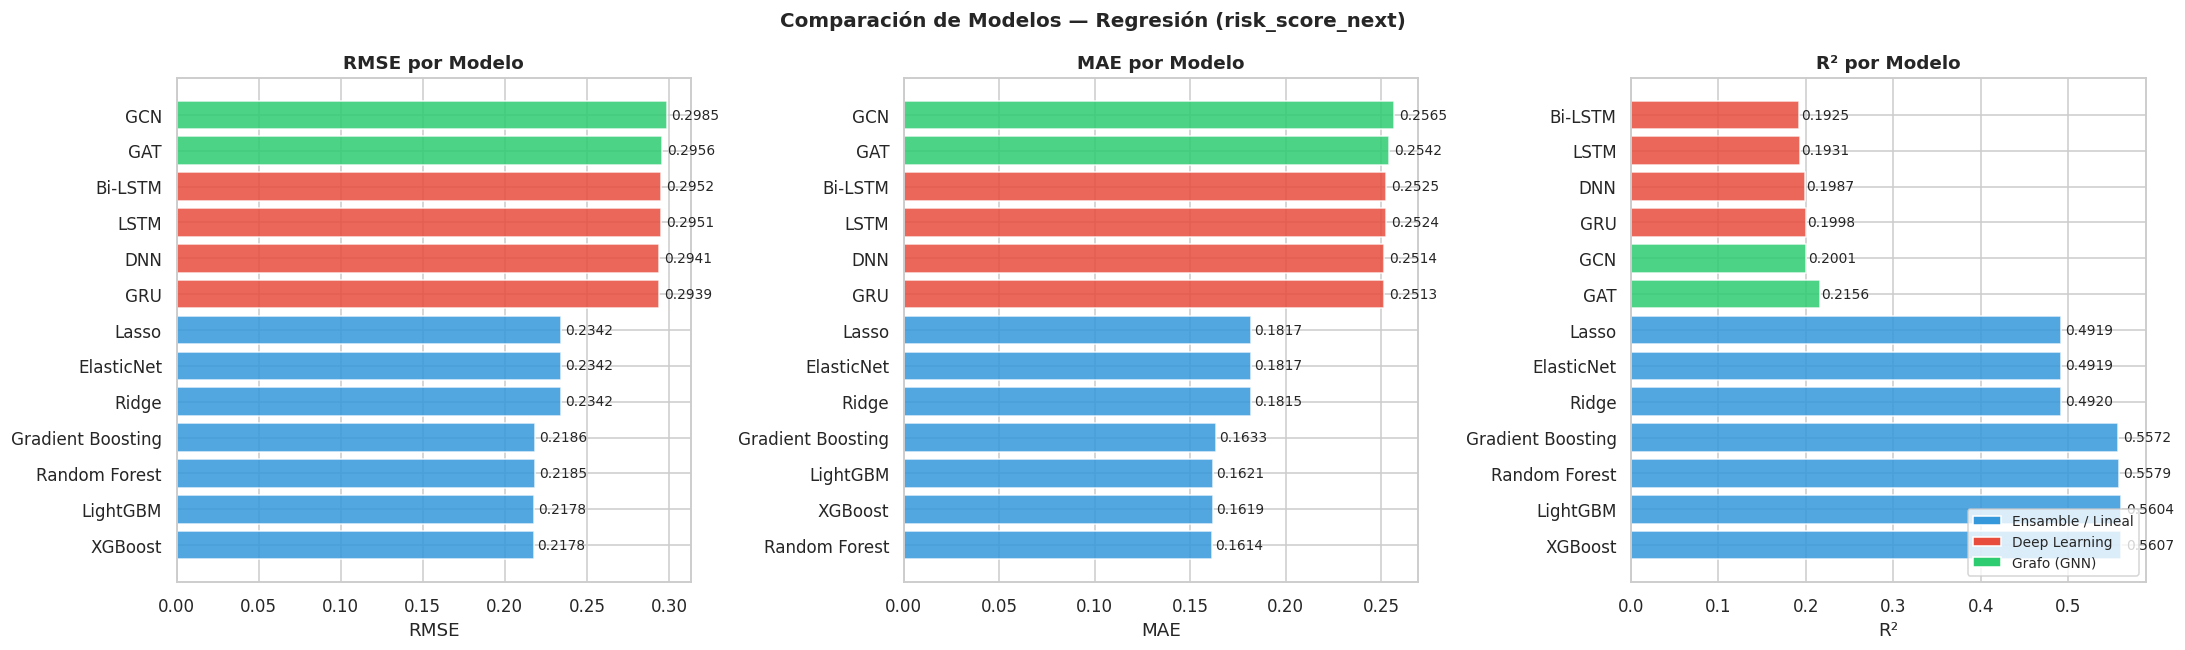

In [14]:
# ── Visualización: métricas de regresión ───────────────────────────────────
familia_colors_r = {'Ensamble / Lineal': '#3498db', 'Deep Learning': '#e74c3c', 'Grafo (GNN)': '#2ecc71'}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
metrics_r = ['RMSE', 'MAE', 'R²']
ascending_r = [True, True, False]

for ax, metric, asc in zip(axes, metrics_r, ascending_r):
    data = df_reg.sort_values(metric, ascending=asc)
    colors = [familia_colors_r.get(f, '#95a5a6') for f in data['Familia']]
    bars = ax.barh(data['Modelo'], data[metric], color=colors, alpha=0.85, edgecolor='white')
    ax.set_title(f'{metric} por Modelo', fontweight='bold')
    ax.set_xlabel(metric)
    for bar, val in zip(bars, data[metric]):
        ax.text(bar.get_width() + bar.get_width()*0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)

from matplotlib.patches import Patch
legend_elems = [Patch(facecolor=v, label=k) for k, v in familia_colors_r.items()]
axes[2].legend(handles=legend_elems, loc='lower right', fontsize=9)

plt.suptitle('Comparación de Modelos — Regresión (risk_score_next)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

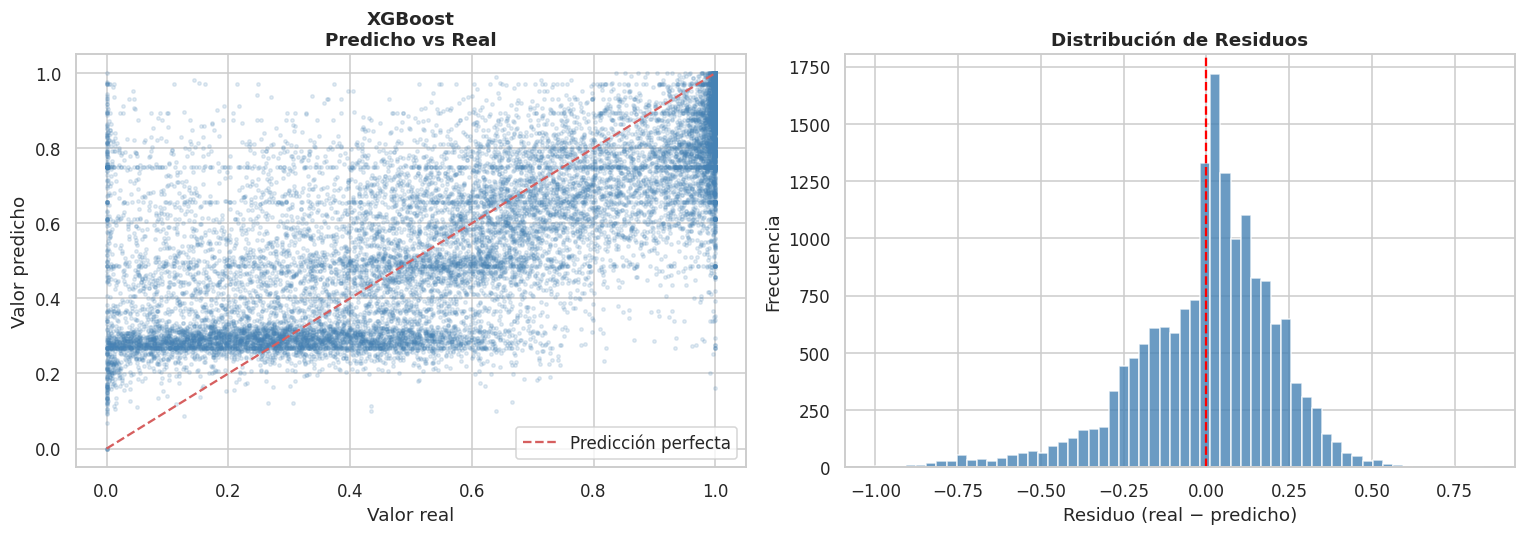

 Mejor modelo de regresión: XGBoost  |  RMSE=0.21777  |  R²=0.56066


In [15]:
# ── Predicho vs Real: mejor modelo ────────────────────────────────────────
best_reg_name  = df_reg.iloc[0]['Modelo']
best_reg_model = regression_models.get(best_reg_name)   # None si es red neuronal

if best_reg_model is not None:
    y_pred_best_r = np.clip(best_reg_model.predict(X_test_r), 0, 1)
else:
    print(f'  {best_reg_name} es una red neuronal — re-entrenando para visualización...')
    builder = {**pytorch_reg_builders, **gnn_reg_builders}.get(best_reg_name)
    m = train_nn(builder(), X_train_r, y_train_r, task='reg', epochs=40)
    raw = predict_nn(m, X_test_r)
    y_pred_best_r = torch.sigmoid(torch.tensor(raw)).numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_r, y_pred_best_r, alpha=0.15, s=5, color='steelblue')
axes[0].plot([0, 1], [0, 1], 'r--', lw=1.5, label='Predicción perfecta')
axes[0].set_xlabel('Valor real')
axes[0].set_ylabel('Valor predicho')
axes[0].set_title(f'{best_reg_name}\nPredicho vs Real', fontweight='bold')
axes[0].legend()

residuals = y_test_r.values - y_pred_best_r.flatten()
axes[1].hist(residuals, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_xlabel('Residuo (real − predicho)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Residuos', fontweight='bold')

plt.tight_layout()
plt.show()
print(f' Mejor modelo de regresión: {best_reg_name}  |  RMSE={df_reg.iloc[0]["RMSE"]:.5f}  |  R²={df_reg.iloc[0]["R²"]:.5f}')

---
## 6. Modelamiento de Clasificación Binaria (**target_distress_next**)

**Selección basada en literatura:**
-  **XGBoost / LightGBM / GBM / RF** — datos tabulares financieros (Alanis 2023, Gelastopoulos 2025)
-  **Logistic Regression** — benchmark interpretable (Kim & Yoon 2023)
-  **DNN** — redes profundas (Steinberg 2023)
-  **LSTM / GRU / Bi-LSTM** — memoria secuencial (Mohamed 2019, Tilly 2021, Zogaan 2025)
- **GCN / GAT** — GCN superó modelos flat en clasificación SEC (Das 2023)

In [16]:
# ── Definición de modelos de clasificación binaria ─────────────────────────
# Selección basada en los artículos de investigación

# --- Modelos sklearn/boosting -----------------------------------------------
binary_models = {
    #  Benchmark lineal — Kim & Yoon (2023)
    'Logistic Regression' : LogisticRegression(max_iter=1000, C=0.5, random_state=RANDOM_STATE),

    #  Ensamble / Boosting — Alanis et al. (2023), Gelastopoulos & Keramydas (2025)
    'Random Forest'       : RandomForestClassifier(n_estimators=300, max_depth=12,
                                                   random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=300, max_depth=5,
                                                        learning_rate=0.05, random_state=RANDOM_STATE),
    'XGBoost'             : xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                                               subsample=0.8, colsample_bytree=0.8,
                                               eval_metric='logloss',
                                               random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    'LightGBM'            : lgb.LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                                                subsample=0.8, colsample_bytree=0.8,
                                                random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
}

# --- Modelos PyTorch --------------------------------------------------------
# DNN — Steinberg et al. (2023)
# LSTM / GRU / Bi-LSTM — Mohamed (2019), Tilly et al. (2021), Zogaan et al. (2025)
pytorch_bin_builders = {
    'DNN'     : lambda: DNNModel(N_FEAT, 1),
    'LSTM'    : lambda: LSTMModel(N_FEAT, 1),
    'GRU'     : lambda: GRUModel(N_FEAT, 1),
    'Bi-LSTM' : lambda: LSTMModel(N_FEAT, 1, bidirectional=True),
}

# --- Modelos GNN ------------------------------------------------------------
# GCN / GAT — Das et al. (2023): GCN/GraphSAGE superó modelos flat en datos SEC
gnn_bin_builders = {
    'GCN' : lambda: GCNModel(N_FEAT, 1),
    'GAT' : lambda: GATModel(N_FEAT, 1),
}

print(f'Modelos binaria — sklearn/boosting: {len(binary_models)} | '
      f'PyTorch: {len(pytorch_bin_builders)} | GNN: {len(gnn_bin_builders)}')
print(f'   Total: {len(binary_models) + len(pytorch_bin_builders) + len(gnn_bin_builders)} modelos')

Modelos binaria — sklearn/boosting: 5 | PyTorch: 4 | GNN: 2
   Total: 11 modelos


In [17]:
# ── Entrenamiento y evaluación — Clasificación Binaria ──────────────────────
bin_results = []
Xtr_b_np = X_train_b.values; Xte_b_np = X_test_b.values
ytr_b_np = y_train_b.values; yte_b_np = y_test_b.values

def _eval_bin(y_true, y_pred, y_prob=None):
    return {
        'Accuracy'  : round(accuracy_score(y_true, y_pred), 4),
        'Precision' : round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall'    : round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1-Score'  : round(f1_score(y_true, y_pred, zero_division=0), 4),
        'ROC-AUC'   : round(roc_auc_score(y_true, y_prob), 4) if y_prob is not None else '—',
    }

# --- sklearn / boosting ---
for name, model in binary_models.items():
    print(f'  Entrenando: {name}...')
    model.fit(Xtr_b_np, ytr_b_np)
    y_pred = model.predict(Xte_b_np)
    y_prob = model.predict_proba(Xte_b_np)[:, 1]
    bin_results.append({'Modelo': name, 'Familia': 'Ensamble / Lineal',
                        **_eval_bin(yte_b_np, y_pred, y_prob)})

# --- PyTorch secuenciales ---
for name, build_fn in pytorch_bin_builders.items():
    print(f'  Entrenando: {name}...')
    m = train_nn(build_fn(), X_train_b, y_train_b, task='bin', epochs=40)
    logits = predict_nn(m, X_test_b)
    probs  = torch.sigmoid(torch.tensor(logits)).numpy().flatten()
    preds  = (probs > 0.5).astype(int)
    bin_results.append({'Modelo': name, 'Familia': 'Deep Learning',
                        **_eval_bin(yte_b_np, preds, probs)})

# --- GNN ---
print(' Construyendo grafos k-NN para GNN binaria...')
idx_tr_b = np.random.choice(len(Xtr_b_np), min(8000, len(Xtr_b_np)), replace=False)
g_tr_b = build_knn_graphs(Xtr_b_np[idx_tr_b], ytr_b_np[idx_tr_b], k=5)
g_te_b = build_knn_graphs(Xte_b_np[:2000],    yte_b_np[:2000],    k=5)

for name, build_fn in gnn_bin_builders.items():
    print(f'  Entrenando: {name}...')
    m = train_gnn(build_fn(), g_tr_b, task='bin', epochs=15)
    logits = predict_gnn(m, g_te_b).flatten()
    probs  = torch.sigmoid(torch.tensor(logits)).numpy()
    preds  = (probs > 0.5).astype(int)
    bin_results.append({'Modelo': name, 'Familia': 'Grafo (GNN)',
                        **_eval_bin(yte_b_np[:2000], preds, probs)})

df_bin = pd.DataFrame(bin_results).sort_values('F1-Score', ascending=False).reset_index(drop=True)
df_bin.index += 1
print('\nEvaluación clasificación binaria completada.')
df_bin

  Entrenando: Logistic Regression...
  Entrenando: Random Forest...
  Entrenando: Gradient Boosting...
  Entrenando: XGBoost...
  Entrenando: LightGBM...
  Entrenando: DNN...
  Entrenando: LSTM...
  Entrenando: GRU...
  Entrenando: Bi-LSTM...
 Construyendo grafos k-NN para GNN binaria...
  Entrenando: GCN...
  Entrenando: GAT...

Evaluación clasificación binaria completada.


,Modelo,Familia,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,GCN,Grafo (GNN),0.8135,0.8218,0.8739,0.8471,0.8758
2,GAT,Grafo (GNN),0.8125,0.8251,0.8663,0.8452,0.8766
3,LSTM,Deep Learning,0.8086,0.8179,0.8740,0.8451,0.8727
4,XGBoost,Ensamble / Lineal,0.8101,0.8268,0.8628,0.8444,0.8769
5,DNN,Deep Learning,0.8094,0.8246,0.8649,0.8442,0.8754
6,Gradient Boosting,Ensamble / Lineal,0.8093,0.8258,0.8627,0.8439,0.8764
7,LightGBM,Ensamble / Lineal,0.8085,0.8265,0.8599,0.8429,0.8766
8,Bi-LSTM,Deep Learning,0.8070,0.8206,0.8663,0.8429,0.8731
9,GRU,Deep Learning,0.8066,0.8234,0.8608,0.8417,0.8732
10,Random Forest,Ensamble / Lineal,0.8059,0.8242,0.8581,0.8408,0.8756


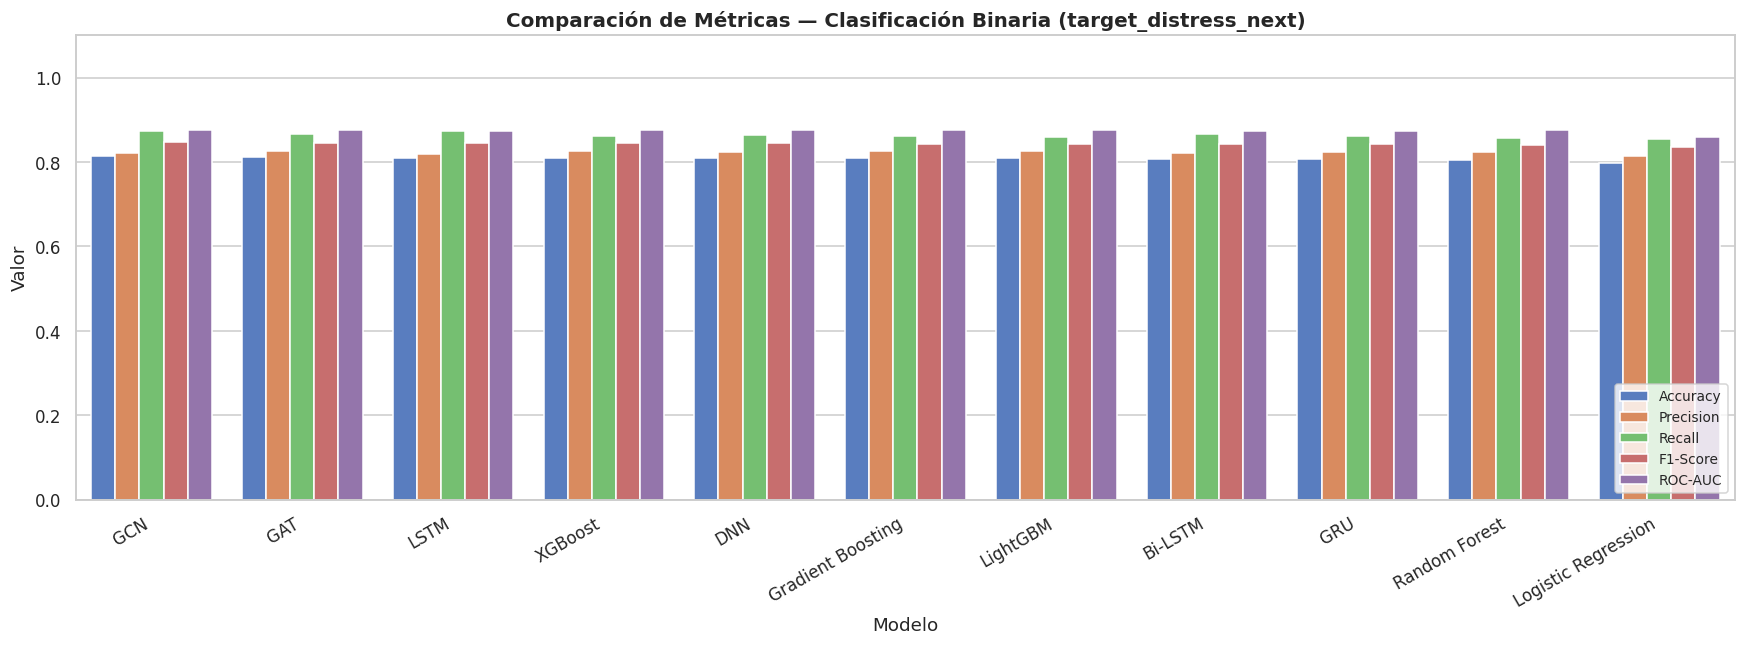

In [18]:
# ── Visualización: métricas clasificación binaria ──────────────────────────
metrics_b = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
df_bin_plot = df_bin.copy()
df_bin_plot['ROC-AUC'] = pd.to_numeric(df_bin_plot['ROC-AUC'], errors='coerce')

df_melt_b = df_bin_plot.melt(id_vars='Modelo', value_vars=metrics_b, var_name='Métrica', value_name='Valor')

fig, ax = plt.subplots(figsize=(16, 6))
sns.barplot(data=df_melt_b, x='Modelo', y='Valor', hue='Métrica', ax=ax)
ax.set_title('Comparación de Métricas — Clasificación Binaria (target_distress_next)', fontweight='bold', fontsize=13)
ax.set_xlabel('Modelo')
ax.set_ylabel('Valor')
ax.set_ylim(0, 1.1)
ax.legend(loc='lower right', fontsize=9)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

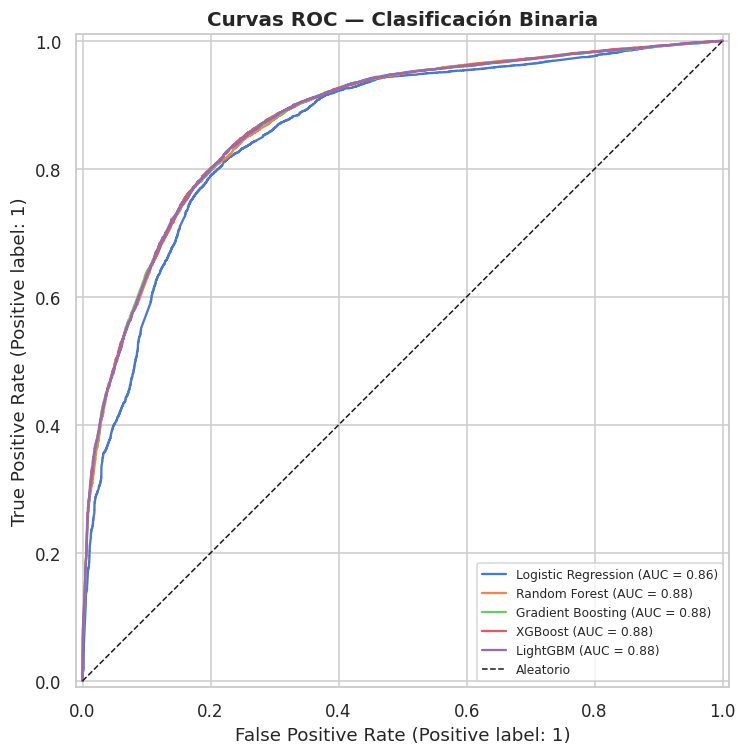

In [19]:
# ── Curvas ROC: todos los modelos ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

for name, model in binary_models.items():
    if hasattr(model, 'predict_proba'):
        y_prob_roc = model.predict_proba(X_test_b)[:, 1]
        RocCurveDisplay.from_predictions(y_test_b, y_prob_roc, name=name, ax=ax)

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatorio')
ax.set_title('Curvas ROC — Clasificación Binaria', fontweight='bold', fontsize=13)
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

  GCN es red neuronal — re-entrenando para visualización...


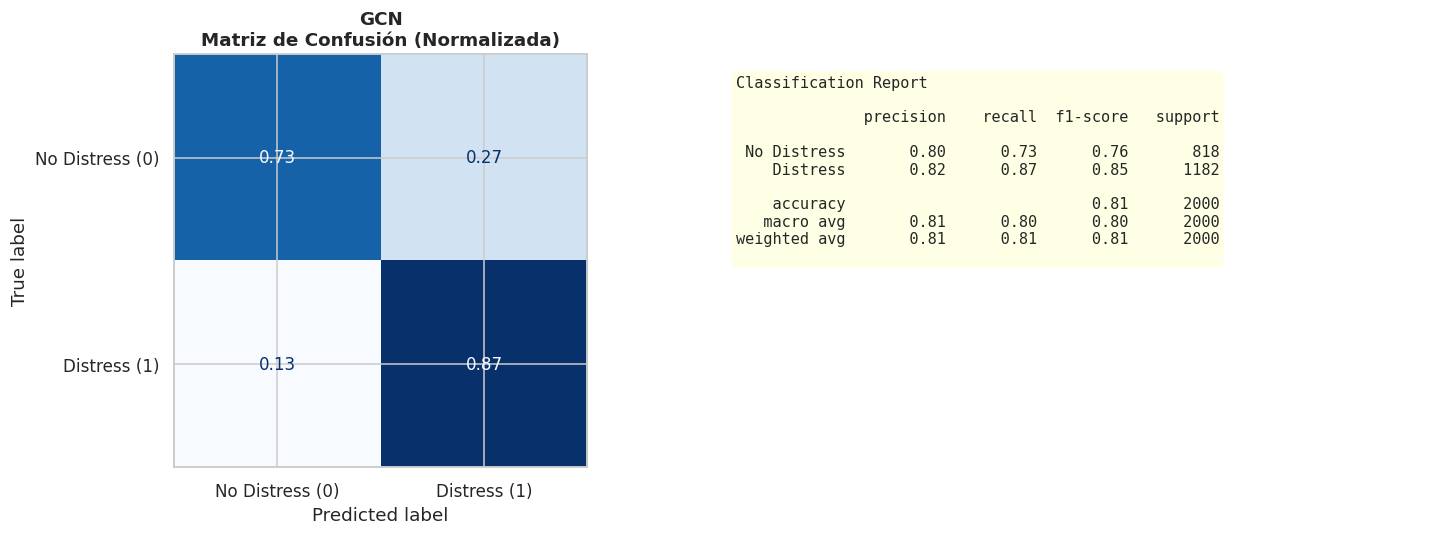

Mejor modelo binario: GCN  |  F1=0.8471  |  ROC-AUC=0.8758


In [21]:
# ── Matriz de confusión: mejor modelo ─────────────────────────────────────
best_bin_name  = df_bin.iloc[0]['Modelo']
best_bin_model = binary_models.get(best_bin_name)  # None if it's a PyTorch or GNN model

# Initialize y_test_b_for_cm for the confusion matrix/classification report
y_test_b_for_cm = yte_b_np # Default to the full numpy array of actuals

if best_bin_model is not None:
    # This block handles sklearn/boosting models
    y_pred_best_b = best_bin_model.predict(Xte_b_np)
else:
    print(f'  {best_bin_name} es red neuronal — re-entrenando para visualización...')
    # Check if the model is a GNN (GCN or GAT)
    if best_bin_name in gnn_bin_builders:
        # Build the GNN model using its specific builder
        builder = gnn_bin_builders.get(best_bin_name)
        # Train the GNN using the dedicated train_gnn function and subsampled graph data
        # Note: 'epochs' for GNNs is lower (15) as per train_gnn calls in cell 1t8cWB_tSL6u
        m = train_gnn(builder(), g_tr_b, task='bin', epochs=15)
        # Predict using the dedicated predict_gnn function and subsampled graph data
        logits = predict_gnn(m, g_te_b).flatten()
        y_pred_best_b = (torch.sigmoid(torch.tensor(logits)).numpy() > 0.5).astype(int)
        # For GNNs, the evaluation data must match the subsampled test graphs
        y_test_b_for_cm = yte_b_np[:len(g_te_b)] # Use the numpy array directly
    else:
        # This block handles other PyTorch models (DNN, LSTM, GRU, Bi-LSTM)
        builder = pytorch_bin_builders.get(best_bin_name)
        # Train the model using the standard train_nn function
        # Note: 'epochs' for non-GNN PyTorch models is higher (40) as per train_nn calls in cell 1t8cWB_tSL6u
        m = train_nn(builder(), X_train_b, y_train_b, task='bin', epochs=40)
        # Predict using the standard predict_nn function
        logits = predict_nn(m, X_test_b)
        y_pred_best_b = (torch.sigmoid(torch.tensor(logits)).numpy().flatten() > 0.5).astype(int)
        # y_test_b_for_cm remains the full test set, as set by default.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Use y_test_b_for_cm for the confusion matrix and classification report
cm_norm = confusion_matrix(y_test_b_for_cm, y_pred_best_b, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=['No Distress (0)', 'Distress (1)'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'{best_bin_name}\nMatriz de Confusión (Normalizada)', fontweight='bold')

report = classification_report(y_test_b_for_cm, y_pred_best_b, target_names=['No Distress', 'Distress'])
axes[1].axis('off')
axes[1].text(0.05, 0.95, 'Classification Report\n\n' + report,
             transform=axes[1].transAxes, fontsize=10, verticalalignment='top',
             fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()
print(f'Mejor modelo binario: {best_bin_name}  |  F1={df_bin.iloc[0]["F1-Score"]:.4f}  |  ROC-AUC={df_bin.iloc[0]["ROC-AUC"]}')

---
## 7. Modelamiento de Clasificación Multiclase (**target_class_next**)

Clases: **0 = Riesgo Bajo | 1 = Riesgo Medio | 2 = Riesgo Alto**

**Selección basada en literatura:**
- **XGBoost / LightGBM / GBM / RF** — mejor desempeño tabular (Alanis 2023, Steinberg 2023)
- **Logistic Regression** — benchmark multiclase multinomial (Kim & Yoon 2023)
- **DNN** — redes profundas (Steinberg 2023)
- **LSTM / GRU / Bi-LSTM** — captura temporal (Zogaan 2025, Tenorio 2025)
- **GCN / GAT** — ST-GNN/GAT mejor para riesgo en redes de empresa (Yang 2020)

In [22]:
# ── Definición de modelos multiclase ───────────────────────────────────────
# Selección basada en los artículos de investigación
N_CLASSES = 3   # 0 = Bajo | 1 = Medio | 2 = Alto

# --- Modelos sklearn/boosting -----------------------------------------------
multiclass_models = {
    # Benchmark lineal multinomial — Kim & Yoon (2023)
    'Logistic Regression' : LogisticRegression(max_iter=1000, multi_class='multinomial',
                                               C=0.5, random_state=RANDOM_STATE),

    # Ensamble / Boosting — Alanis et al. (2023), Steinberg et al. (2023)
    'Random Forest'       : RandomForestClassifier(n_estimators=300, max_depth=12,
                                                   random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=300, max_depth=5,
                                                        learning_rate=0.05, random_state=RANDOM_STATE),
    'XGBoost'             : xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                                               subsample=0.8, colsample_bytree=0.8,
                                               objective='multi:softprob', num_class=N_CLASSES,
                                               eval_metric='mlogloss',
                                               random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    'LightGBM'            : lgb.LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                                                subsample=0.8, colsample_bytree=0.8,
                                                objective='multiclass', num_class=N_CLASSES,
                                                random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
}

# --- Modelos PyTorch --------------------------------------------------------
# DNN — Steinberg et al. (2023)
# LSTM / GRU / Bi-LSTM — Zogaan et al. (2025), Tenorio et al. (2025)
pytorch_mc_builders = {
    'DNN'     : lambda: DNNModel(N_FEAT, N_CLASSES),
    'LSTM'    : lambda: LSTMModel(N_FEAT, N_CLASSES),
    'GRU'     : lambda: GRUModel(N_FEAT, N_CLASSES),
    'Bi-LSTM' : lambda: LSTMModel(N_FEAT, N_CLASSES, bidirectional=True),
}

# --- Modelos GNN ------------------------------------------------------------
# GCN / GAT — Yang et al. (2020): ST-GNN/GAT mejor para riesgo en redes dinámicas
gnn_mc_builders = {
    'GCN' : lambda: GCNModel(N_FEAT, N_CLASSES),
    'GAT' : lambda: GATModel(N_FEAT, N_CLASSES),
}

print(f'Modelos multiclase — sklearn/boosting: {len(multiclass_models)} | '
      f'PyTorch: {len(pytorch_mc_builders)} | GNN: {len(gnn_mc_builders)}')
print(f'   Total: {len(multiclass_models) + len(pytorch_mc_builders) + len(gnn_mc_builders)} modelos')

Modelos multiclase — sklearn/boosting: 5 | PyTorch: 4 | GNN: 2
   Total: 11 modelos


In [23]:
# ── Entrenamiento y evaluación — Clasificación Multiclase ──────────────────
mc_results = []
Xtr_m_np = X_train_m.values; Xte_m_np = X_test_m.values
ytr_m_np = y_train_m.values; yte_m_np = y_test_m.values

def _eval_mc(y_true, y_pred, y_prob=None):
    roc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro') \
          if y_prob is not None else np.nan
    return {
        'Accuracy'        : round(accuracy_score(y_true, y_pred), 4),
        'F1 Macro'        : round(f1_score(y_true, y_pred, average='macro',    zero_division=0), 4),
        'F1 Weighted'     : round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'Precision Macro' : round(precision_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'Recall Macro'    : round(recall_score(y_true, y_pred, average='macro',    zero_division=0), 4),
        'ROC-AUC OvR'     : round(roc, 4) if not np.isnan(roc) else '—',
    }

# --- sklearn / boosting ---
for name, model in multiclass_models.items():
    print(f'  Entrenando: {name}...')
    model.fit(Xtr_m_np, ytr_m_np)
    y_pred = model.predict(Xte_m_np)
    y_prob = model.predict_proba(Xte_m_np)
    mc_results.append({'Modelo': name, 'Familia': 'Ensamble / Lineal',
                       **_eval_mc(yte_m_np, y_pred, y_prob)})

# --- PyTorch secuenciales ---
for name, build_fn in pytorch_mc_builders.items():
    print(f'  Entrenando: {name}...')
    m = train_nn(build_fn(), X_train_m, y_train_m, task='multi', epochs=40)
    logits = predict_nn(m, X_test_m)
    probs  = torch.softmax(torch.tensor(logits), dim=-1).numpy()
    preds  = probs.argmax(axis=1)
    mc_results.append({'Modelo': name, 'Familia': 'Deep Learning',
                       **_eval_mc(yte_m_np, preds, probs)})

# --- GNN ---
print('  Construyendo grafos k-NN para GNN multiclase...')
idx_tr_m = np.random.choice(len(Xtr_m_np), min(8000, len(Xtr_m_np)), replace=False)
g_tr_m = build_knn_graphs(Xtr_m_np[idx_tr_m], ytr_m_np[idx_tr_m], k=5)
g_te_m = build_knn_graphs(Xte_m_np[:2000],    yte_m_np[:2000],    k=5)

for name, build_fn in gnn_mc_builders.items():
    print(f'  Entrenando: {name}...')
    m = train_gnn(build_fn(), g_tr_m, task='multi', epochs=15)
    logits = predict_gnn(m, g_te_m)
    probs  = torch.softmax(torch.tensor(logits), dim=-1).numpy()
    preds  = probs.argmax(axis=1)
    mc_results.append({'Modelo': name, 'Familia': 'Grafo (GNN)',
                       **_eval_mc(yte_m_np[:2000], preds, probs)})

df_mc = pd.DataFrame(mc_results).sort_values('F1 Macro', ascending=False).reset_index(drop=True)
df_mc.index += 1
print('\nEvaluación clasificación multiclase completada.')
df_mc

  Entrenando: Logistic Regression...
  Entrenando: Random Forest...
  Entrenando: Gradient Boosting...
  Entrenando: XGBoost...
  Entrenando: LightGBM...
  Entrenando: DNN...
  Entrenando: LSTM...
  Entrenando: GRU...
  Entrenando: Bi-LSTM...
  Construyendo grafos k-NN para GNN multiclase...
  Entrenando: GCN...
  Entrenando: GAT...

Evaluación clasificación multiclase completada.


,Modelo,Familia,Accuracy,F1 Macro,F1 Weighted,Precision Macro,Recall Macro,ROC-AUC OvR
1,XGBoost,Ensamble / Lineal,0.6861,0.6284,0.6685,0.6406,0.6321,0.8377
2,LightGBM,Ensamble / Lineal,0.6846,0.6270,0.6670,0.6391,0.6306,0.8375
3,Gradient Boosting,Ensamble / Lineal,0.6829,0.6258,0.6658,0.6370,0.6294,0.8376
4,Bi-LSTM,Deep Learning,0.6797,0.6253,0.6649,0.6346,0.6265,0.8307
5,Random Forest,Ensamble / Lineal,0.6821,0.6225,0.6629,0.6363,0.6272,0.8357
6,LSTM,Deep Learning,0.6809,0.6223,0.6628,0.6338,0.6264,0.8312
7,GRU,Deep Learning,0.6809,0.6219,0.6624,0.6344,0.6255,0.8313
8,DNN,Deep Learning,0.6818,0.6197,0.6611,0.6340,0.6254,0.8340
9,Logistic Regression,Ensamble / Lineal,0.6758,0.6019,0.6457,0.6290,0.6139,0.8171
10,GCN,Grafo (GNN),0.6700,0.5995,0.6468,0.6133,0.6068,0.8171


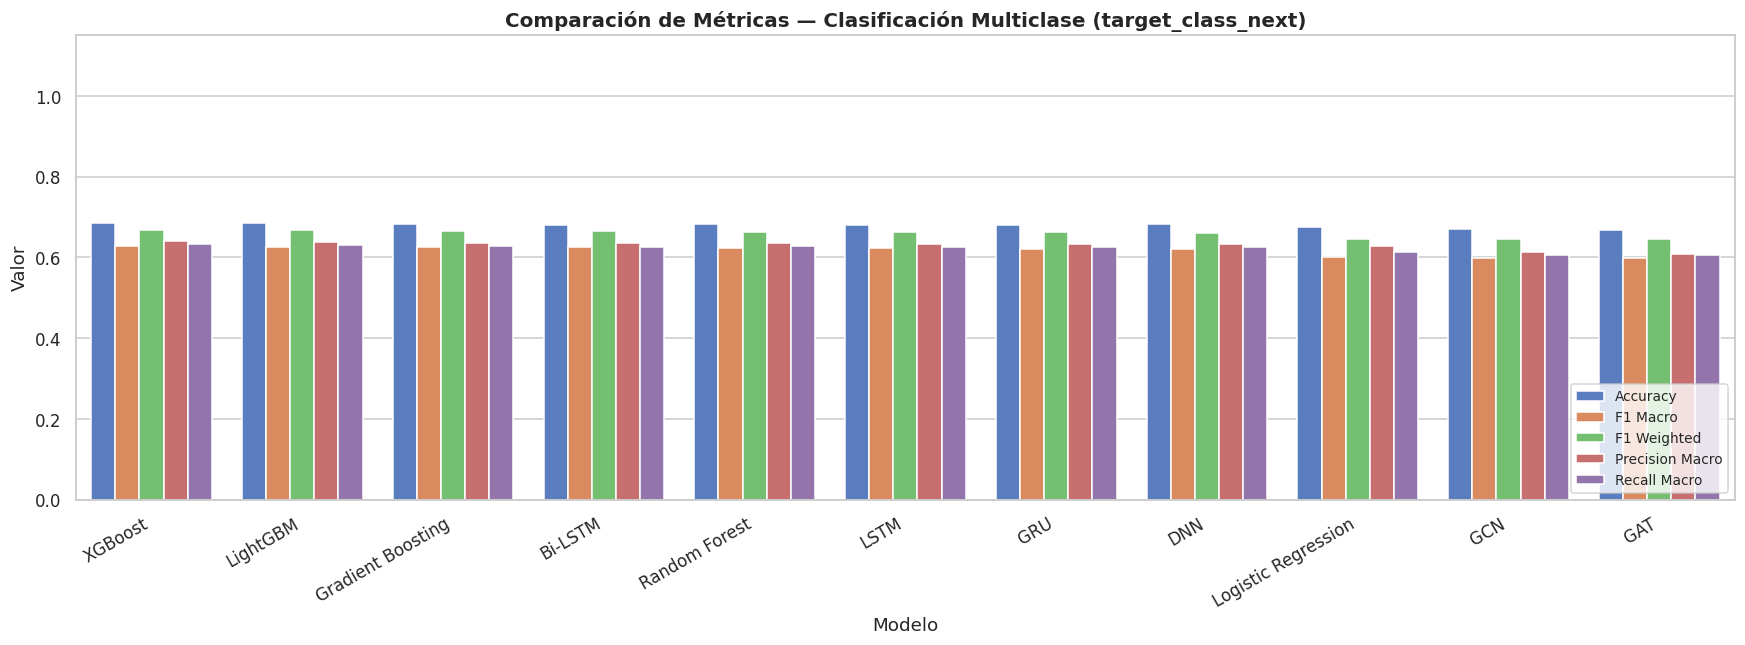

In [24]:
# ── Visualización: métricas multiclase ─────────────────────────────────────
metrics_mc_plot = ['Accuracy', 'F1 Macro', 'F1 Weighted', 'Precision Macro', 'Recall Macro']
df_mc_plot = df_mc.copy()

df_melt_mc = df_mc_plot.melt(id_vars='Modelo', value_vars=metrics_mc_plot, var_name='Métrica', value_name='Valor')

fig, ax = plt.subplots(figsize=(16, 6))
sns.barplot(data=df_melt_mc, x='Modelo', y='Valor', hue='Métrica', ax=ax)
ax.set_title('Comparación de Métricas — Clasificación Multiclase (target_class_next)', fontweight='bold', fontsize=13)
ax.set_xlabel('Modelo')
ax.set_ylabel('Valor')
ax.set_ylim(0, 1.15)
ax.legend(loc='lower right', fontsize=9)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

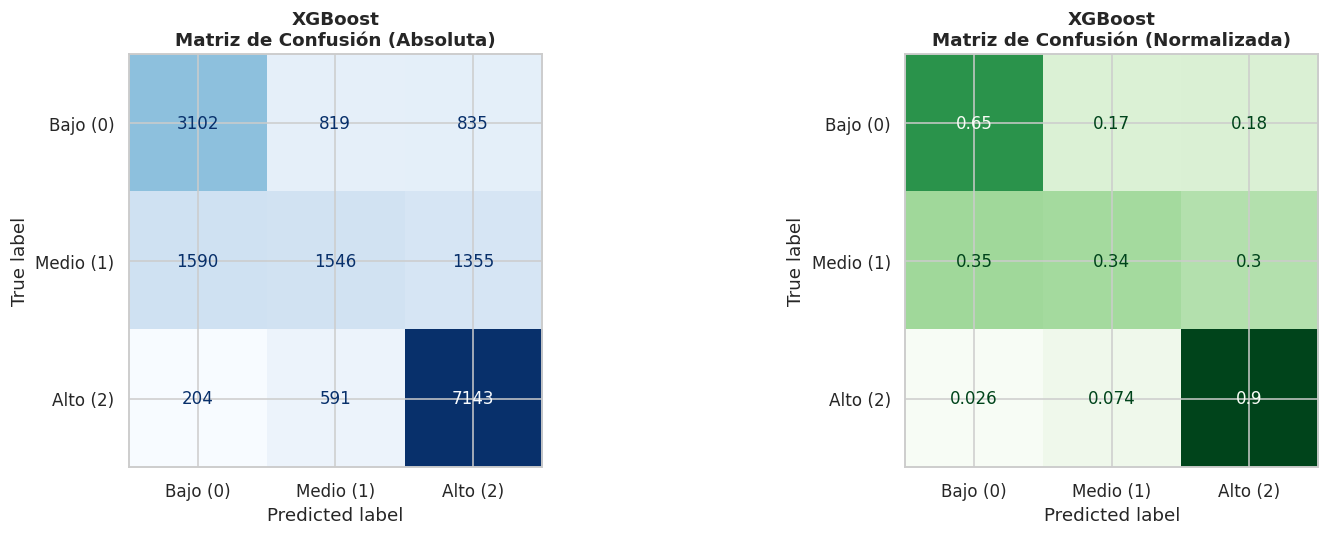


Classification Report — XGBoost
              precision    recall  f1-score   support

    Bajo (0)       0.63      0.65      0.64      4756
   Medio (1)       0.52      0.34      0.42      4491
    Alto (2)       0.77      0.90      0.83      7938

    accuracy                           0.69     17185
   macro avg       0.64      0.63      0.63     17185
weighted avg       0.67      0.69      0.67     17185

Mejor modelo multiclase: XGBoost  |  F1 Macro=0.6284


In [25]:
# ── Matrices de confusión: mejor modelo ────────────────────────────────────
best_mc_name  = df_mc.iloc[0]['Modelo']
best_mc_model = multiclass_models.get(best_mc_name)  # None si es red neuronal

if best_mc_model is not None:
    y_pred_best_m = best_mc_model.predict(Xte_m_np)
else:
    print(f' {best_mc_name} es red neuronal — re-entrenando para visualización...')
    builder = {**pytorch_mc_builders, **gnn_mc_builders}.get(best_mc_name)
    m = train_nn(builder(), X_train_m, y_train_m, task='multi', epochs=40)
    logits = predict_nn(m, X_test_m)
    y_pred_best_m = torch.softmax(torch.tensor(logits), dim=-1).numpy().argmax(axis=1)

class_names = ['Bajo (0)', 'Medio (1)', 'Alto (2)']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Absoluta
cm_abs = confusion_matrix(y_test_m, y_pred_best_m)
ConfusionMatrixDisplay(confusion_matrix=cm_abs, display_labels=class_names).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'{best_mc_name}\nMatriz de Confusión (Absoluta)', fontweight='bold')

# Normalizada
cm_norm = confusion_matrix(y_test_m, y_pred_best_m, normalize='true')
ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names).plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title(f'{best_mc_name}\nMatriz de Confusión (Normalizada)', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\nClassification Report — {best_mc_name}')
print(classification_report(y_test_m, y_pred_best_m, target_names=class_names))
print(f'Mejor modelo multiclase: {best_mc_name}  |  F1 Macro={df_mc.iloc[0]["F1 Macro"]:.4f}')

---
## 8. Importancia de Features — Mejores Modelos

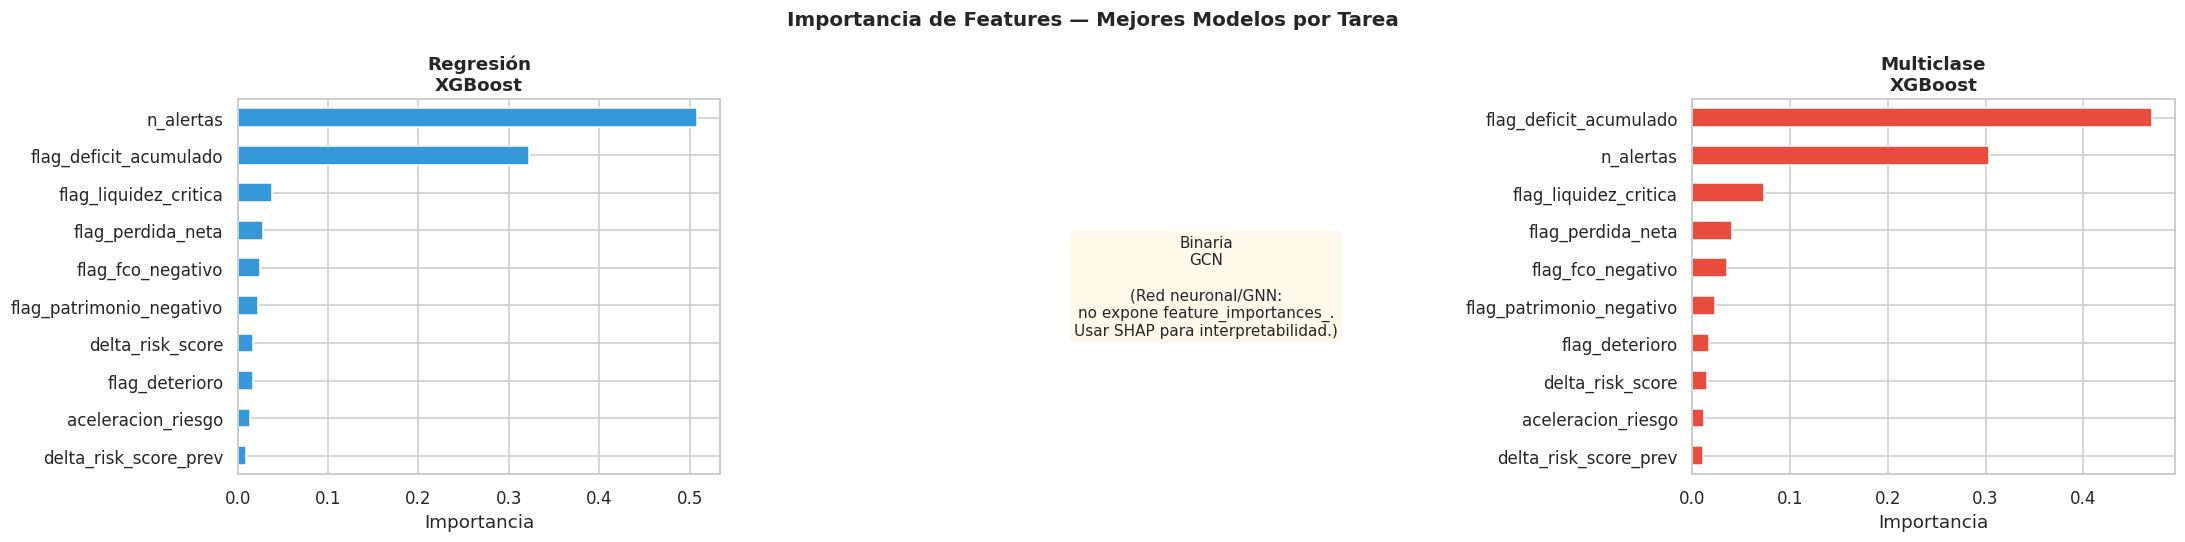

In [26]:
def plot_feature_importance(model, feature_names, title, ax, color='steelblue', top_n=14):
    """Grafica importancia de features. Soporta modelos sklearn/boosting con feature_importances_."""
    if not hasattr(model, 'feature_importances_'):
        ax.text(0.5, 0.5, f'{title}\n\n(Red neuronal/GNN:\nno expone feature_importances_.\nUsar SHAP para interpretabilidad.)',
                ha='center', va='center', transform=ax.transAxes, fontsize=10,
                bbox=dict(boxstyle='round', facecolor='#fef9e7', alpha=0.8))
        ax.axis('off')
        return
    importances = pd.Series(model.feature_importances_, index=feature_names)
    importances = importances.sort_values(ascending=True).tail(top_n)
    importances.plot(kind='barh', ax=ax, color=color, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Importancia')

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

best_reg_model_fi  = regression_models.get(best_reg_name)
best_bin_model_fi  = binary_models.get(best_bin_name)
best_mc_model_fi   = multiclass_models.get(best_mc_name)

plot_feature_importance(best_reg_model_fi,  FEATURE_COLS, f'Regresión\n{best_reg_name}',  axes[0], color='#3498db')
plot_feature_importance(best_bin_model_fi,  FEATURE_COLS, f'Binaria\n{best_bin_name}',    axes[1], color='#2ecc71')
plot_feature_importance(best_mc_model_fi,   FEATURE_COLS, f'Multiclase\n{best_mc_name}',  axes[2], color='#e74c3c')

plt.suptitle('Importancia de Features — Mejores Modelos por Tarea', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Validación Cruzada — Mejores Modelos

In [27]:
print('Validación cruzada (5-fold) — mejor modelo sklearn/boosting por tarea...')
print('   (Los modelos de redes neuronales y GNN no son compatibles con cross_val_score;')
print('    su estabilidad se estima con múltiples ejecuciones o k-fold manual.)')
cv_results = {}

# Seleccionar el mejor modelo sklearn/boosting (si el top-1 es red neuronal, tomar el siguiente)
def _best_sklearn(df_results, model_dict):
    for _, row in df_results.iterrows():
        if row['Modelo'] in model_dict:
            return row['Modelo'], model_dict[row['Modelo']]
    return None, None

# Regresión
best_reg_cv_name, best_reg_cv_model = _best_sklearn(df_reg, regression_models)
if best_reg_cv_model:
    cv_r = cross_val_score(best_reg_cv_model, X_processed, y_reg,
                           cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),
                           scoring='r2', n_jobs=-1)
    cv_results[f'Regresión — {best_reg_cv_name} (R²)'] = cv_r
    print(f'  Regresión ({best_reg_cv_name})   R²: {cv_r.mean():.4f} ± {cv_r.std():.4f}')

# Binaria
best_bin_cv_name, best_bin_cv_model = _best_sklearn(df_bin, binary_models)
if best_bin_cv_model:
    cv_b = cross_val_score(best_bin_cv_model, X_processed, y_bin,
                           cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                           scoring='f1', n_jobs=-1)
    cv_results[f'Binaria — {best_bin_cv_name} (F1)'] = cv_b
    print(f'  Binaria    ({best_bin_cv_name})  F1 : {cv_b.mean():.4f} ± {cv_b.std():.4f}')

# Multiclase
best_mc_cv_name, best_mc_cv_model = _best_sklearn(df_mc, multiclass_models)
if best_mc_cv_model:
    cv_m = cross_val_score(best_mc_cv_model, X_processed, y_mc,
                           cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                           scoring='f1_macro', n_jobs=-1)
    cv_results[f'Multiclase — {best_mc_cv_name} (F1 Macro)'] = cv_m
    print(f'  Multiclase ({best_mc_cv_name})  F1M: {cv_m.mean():.4f} ± {cv_m.std():.4f}')

Validación cruzada (5-fold) — mejor modelo sklearn/boosting por tarea...
   (Los modelos de redes neuronales y GNN no son compatibles con cross_val_score;
    su estabilidad se estima con múltiples ejecuciones o k-fold manual.)
  Regresión (XGBoost)   R²: 0.5652 ± 0.0060
  Binaria    (XGBoost)  F1 : 0.8433 ± 0.0021
  Multiclase (XGBoost)  F1M: 0.6265 ± 0.0024


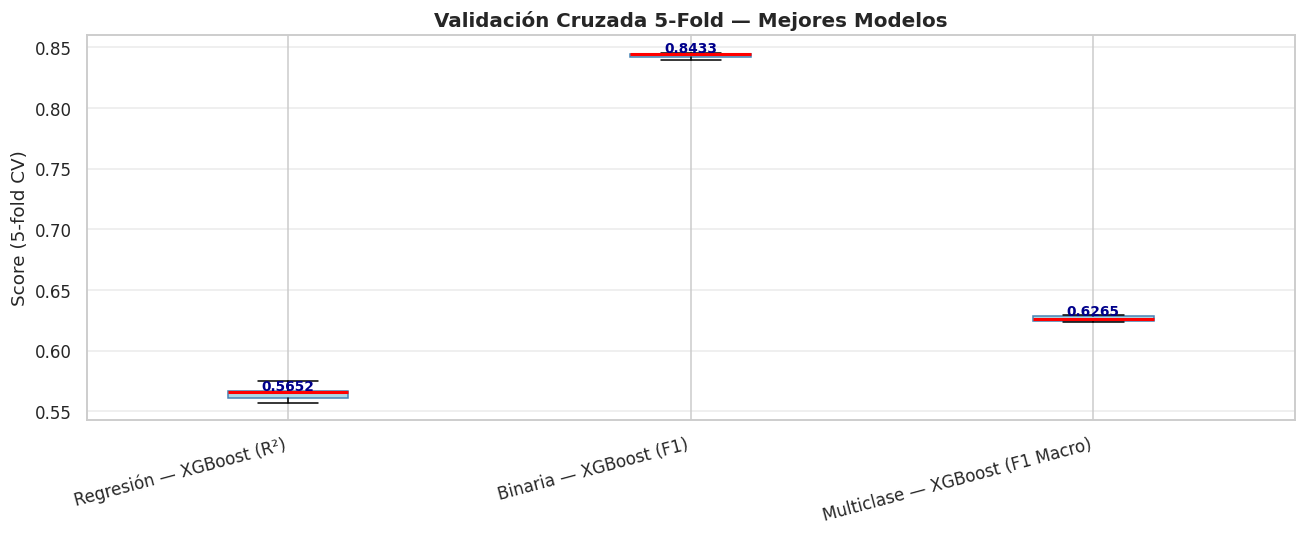

In [28]:
# ── Boxplot de validación cruzada ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

labels = list(cv_results.keys())
data   = [cv_results[k] for k in labels]

bp = ax.boxplot(data, patch_artist=True, vert=True,
                boxprops=dict(facecolor='lightblue', color='steelblue'),
                medianprops=dict(color='red', linewidth=2))

ax.set_xticks(range(1, len(labels)+1))
ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylabel('Score (5-fold CV)')
ax.set_title('Validación Cruzada 5-Fold — Mejores Modelos', fontweight='bold', fontsize=13)
ax.grid(axis='y', alpha=0.4)

for i, d in enumerate(data, 1):
    ax.text(i, d.mean(), f'{d.mean():.4f}', ha='center', va='bottom', fontsize=9, color='darkblue', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 10. Tabla de Comparación Global — Resumen por Variable Objetivo

In [29]:
# ══════════════════════════════════════════════════════════════════════════════
# REGRESIÓN: risk_score_next
# ══════════════════════════════════════════════════════════════════════════════
print('=' * 70)
print('REGRESIÓN: risk_score_next')
print('=' * 70)
df_reg_show = df_reg[['Modelo', 'RMSE', 'MAE', 'R²', 'MAPE']].copy()
df_reg_show = df_reg_show.sort_values('RMSE').reset_index(drop=True)
df_reg_show.index += 1
# Destacar mejor fila
def highlight_best_reg(row):
    return ['background-color: #d4edda; font-weight: bold' if row.name == 1 else '' for _ in row]
display(df_reg_show.style.apply(highlight_best_reg, axis=1).format({'RMSE':'{:.5f}','MAE':'{:.5f}','R²':'{:.5f}','MAPE':'{:.5f}'}))
print(f'\n   Mejor: {df_reg_show.iloc[0]["Modelo"]} — RMSE={df_reg_show.iloc[0]["RMSE"]:.5f}, R²={df_reg_show.iloc[0]["R²"]:.5f}')

REGRESIÓN: risk_score_next


,Modelo,RMSE,MAE,R²,MAPE
1,XGBoost,0.21777,0.16189,0.56066,2.57533
2,LightGBM,0.21784,0.16208,0.56040,2.58348
3,Random Forest,0.21846,0.16144,0.55787,2.52369
4,Gradient Boosting,0.21863,0.16329,0.55718,2.62076
5,Ridge,0.23417,0.18153,0.49202,2.78343
6,ElasticNet,0.23419,0.18165,0.49189,2.78794
7,Lasso,0.23420,0.18173,0.49185,2.79229
8,GRU,0.29391,0.25133,0.19977,3.85239
9,DNN,0.29410,0.25135,0.19869,3.87733
10,LSTM,0.29512,0.25236,0.19315,3.87147



   Mejor: XGBoost — RMSE=0.21777, R²=0.56066


In [30]:
# ══════════════════════════════════════════════════════════════════════════════
# CLASIFICACIÓN BINARIA: target_distress_next
# ══════════════════════════════════════════════════════════════════════════════
print('=' * 70)
print('CLASIFICACIÓN BINARIA: target_distress_next')
print('=' * 70)
df_bin_show = df_bin[['Modelo', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].copy()
df_bin_show = df_bin_show.sort_values('F1-Score', ascending=False).reset_index(drop=True)
df_bin_show.index += 1
def highlight_best_bin(row):
    return ['background-color: #d4edda; font-weight: bold' if row.name == 1 else '' for _ in row]
display(df_bin_show.style.apply(highlight_best_bin, axis=1).format({'Accuracy':'{:.4f}','Precision':'{:.4f}','Recall':'{:.4f}','F1-Score':'{:.4f}'}))
print(f'\n   Mejor: {df_bin_show.iloc[0]["Modelo"]} — F1={df_bin_show.iloc[0]["F1-Score"]:.4f}, ROC-AUC={df_bin_show.iloc[0]["ROC-AUC"]}')

CLASIFICACIÓN BINARIA: target_distress_next


,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,GCN,0.8135,0.8218,0.8739,0.8471,0.875800
2,GAT,0.8125,0.8251,0.8663,0.8452,0.876600
3,LSTM,0.8086,0.8179,0.8740,0.8451,0.872700
4,XGBoost,0.8101,0.8268,0.8628,0.8444,0.876900
5,DNN,0.8094,0.8246,0.8649,0.8442,0.875400
6,Gradient Boosting,0.8093,0.8258,0.8627,0.8439,0.876400
7,LightGBM,0.8085,0.8265,0.8599,0.8429,0.876600
8,Bi-LSTM,0.8070,0.8206,0.8663,0.8429,0.873100
9,GRU,0.8066,0.8234,0.8608,0.8417,0.873200
10,Random Forest,0.8059,0.8242,0.8581,0.8408,0.875600



   Mejor: GCN — F1=0.8471, ROC-AUC=0.8758


In [31]:
# ══════════════════════════════════════════════════════════════════════════════
# CLASIFICACIÓN MULTICLASE: target_class_next
# ══════════════════════════════════════════════════════════════════════════════
print('=' * 70)
print('TAREA 3 — CLASIFICACIÓN MULTICLASE: target_class_next')
print('=' * 70)
df_mc_show = df_mc[['Modelo', 'Accuracy', 'F1 Macro', 'F1 Weighted', 'Precision Macro', 'Recall Macro', 'ROC-AUC OvR']].copy()
df_mc_show = df_mc_show.sort_values('F1 Macro', ascending=False).reset_index(drop=True)
df_mc_show.index += 1
def highlight_best_mc(row):
    return ['background-color: #d4edda; font-weight: bold' if row.name == 1 else '' for _ in row]
display(df_mc_show.style.apply(highlight_best_mc, axis=1).format({'Accuracy':'{:.4f}','F1 Macro':'{:.4f}','F1 Weighted':'{:.4f}','Precision Macro':'{:.4f}','Recall Macro':'{:.4f}'}))
print(f'\n   Mejor: {df_mc_show.iloc[0]["Modelo"]} — F1 Macro={df_mc_show.iloc[0]["F1 Macro"]:.4f}')

TAREA 3 — CLASIFICACIÓN MULTICLASE: target_class_next


,Modelo,Accuracy,F1 Macro,F1 Weighted,Precision Macro,Recall Macro,ROC-AUC OvR
1,XGBoost,0.6861,0.6284,0.6685,0.6406,0.6321,0.837700
2,LightGBM,0.6846,0.6270,0.6670,0.6391,0.6306,0.837500
3,Gradient Boosting,0.6829,0.6258,0.6658,0.6370,0.6294,0.837600
4,Bi-LSTM,0.6797,0.6253,0.6649,0.6346,0.6265,0.830700
5,Random Forest,0.6821,0.6225,0.6629,0.6363,0.6272,0.835700
6,LSTM,0.6809,0.6223,0.6628,0.6338,0.6264,0.831200
7,GRU,0.6809,0.6219,0.6624,0.6344,0.6255,0.831300
8,DNN,0.6818,0.6197,0.6611,0.6340,0.6254,0.834000
9,Logistic Regression,0.6758,0.6019,0.6457,0.6290,0.6139,0.817100
10,GCN,0.6700,0.5995,0.6468,0.6133,0.6068,0.817100



   Mejor: XGBoost — F1 Macro=0.6284


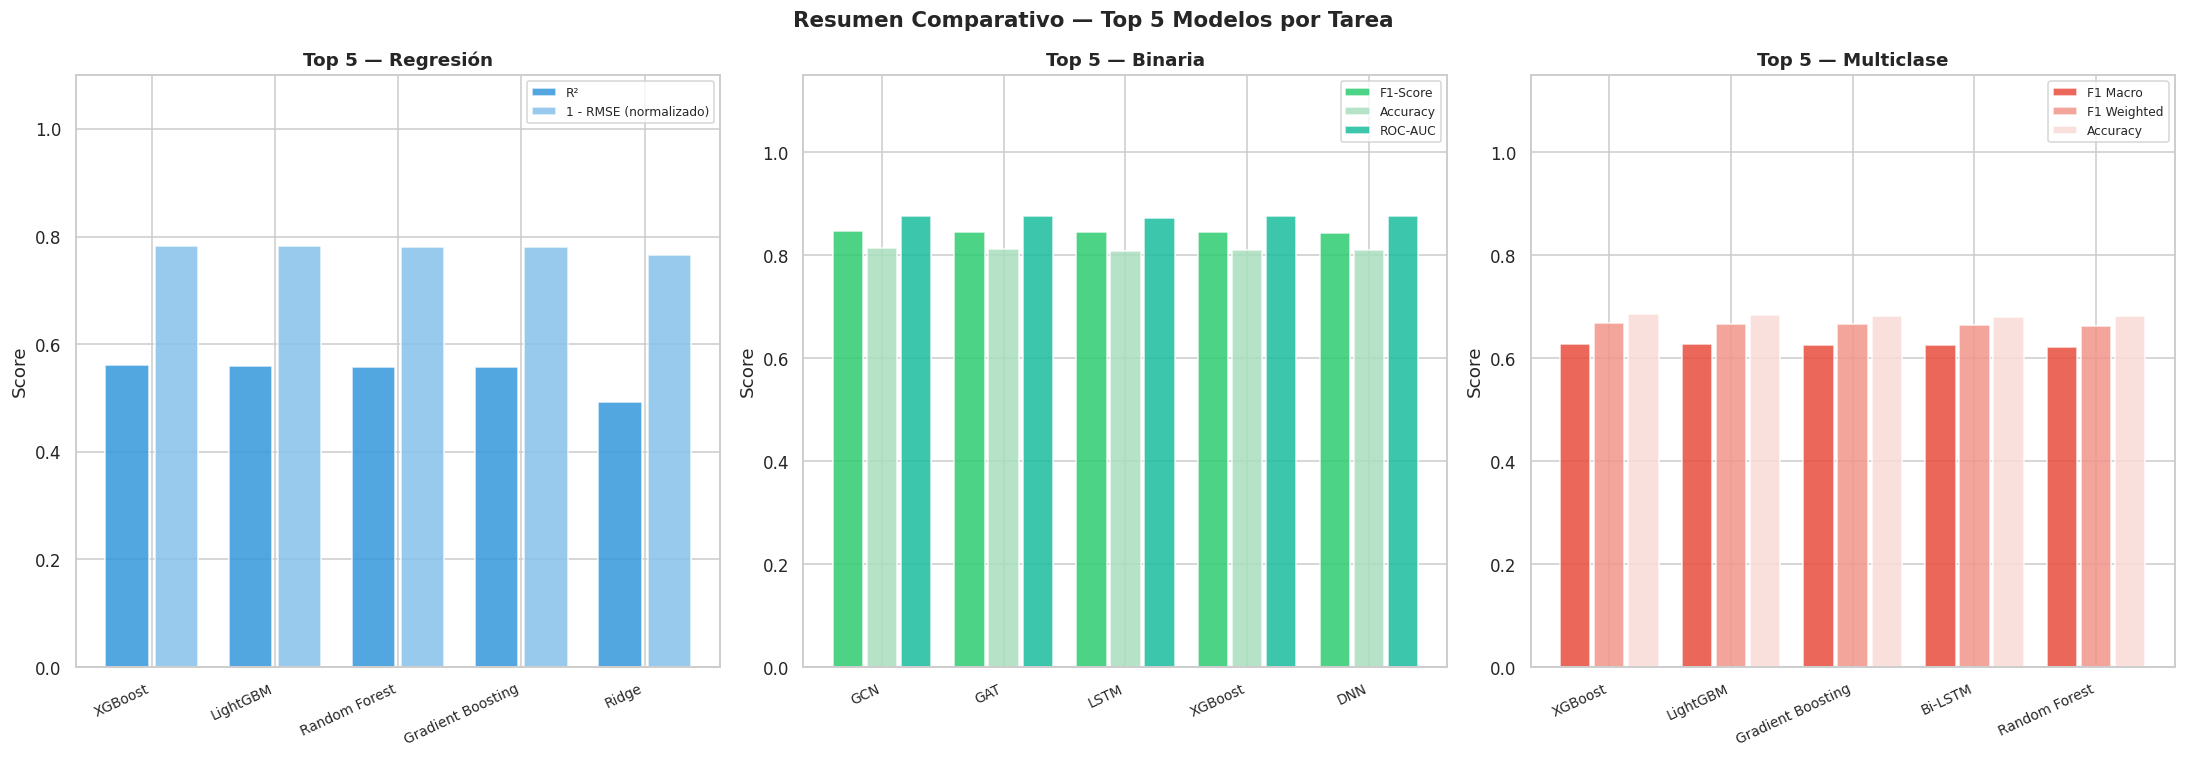

In [32]:
# ── Gráfico resumen: radar de mejores modelos ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# --- Panel 1: Regresión ---
ax = axes[0]
top5_r = df_reg_show.head(5)
x = np.arange(len(top5_r))
ax.bar(x, top5_r['R²'], color='#3498db', alpha=0.85, label='R²', width=0.35)
ax.bar(x + 0.4, 1 - top5_r['RMSE'], color='#85c1e9', alpha=0.85, label='1 - RMSE (normalizado)', width=0.35)
ax.set_xticks(x + 0.2)
ax.set_xticklabels(top5_r['Modelo'], rotation=25, ha='right', fontsize=9)
ax.set_ylim(0, 1.1)
ax.set_title('Top 5 — Regresión', fontweight='bold')
ax.legend(fontsize=8)
ax.set_ylabel('Score')

# --- Panel 2: Binaria ---
ax = axes[1]
top5_b = df_bin_show.head(5)
x = np.arange(len(top5_b))
ax.bar(x, top5_b['F1-Score'], color='#2ecc71', alpha=0.85, label='F1-Score', width=0.25)
ax.bar(x + 0.28, top5_b['Accuracy'], color='#a9dfbf', alpha=0.85, label='Accuracy', width=0.25)
roc_vals = pd.to_numeric(top5_b['ROC-AUC'], errors='coerce').fillna(0)
ax.bar(x + 0.56, roc_vals, color='#1abc9c', alpha=0.85, label='ROC-AUC', width=0.25)
ax.set_xticks(x + 0.28)
ax.set_xticklabels(top5_b['Modelo'], rotation=25, ha='right', fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_title('Top 5 — Binaria', fontweight='bold')
ax.legend(fontsize=8)
ax.set_ylabel('Score')

# --- Panel 3: Multiclase ---
ax = axes[2]
top5_m = df_mc_show.head(5)
x = np.arange(len(top5_m))
ax.bar(x, top5_m['F1 Macro'], color='#e74c3c', alpha=0.85, label='F1 Macro', width=0.25)
ax.bar(x + 0.28, top5_m['F1 Weighted'], color='#f1948a', alpha=0.85, label='F1 Weighted', width=0.25)
ax.bar(x + 0.56, top5_m['Accuracy'], color='#fadbd8', alpha=0.85, label='Accuracy', width=0.25)
ax.set_xticks(x + 0.28)
ax.set_xticklabels(top5_m['Modelo'], rotation=25, ha='right', fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_title('Top 5 — Multiclase', fontweight='bold')
ax.legend(fontsize=8)
ax.set_ylabel('Score')

plt.suptitle('Resumen Comparativo — Top 5 Modelos por Tarea', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 11. Conclusiones del Modelamiento

> Ejecuta las celdas anteriores para que esta sección se llene con los resultados reales.

In [34]:
print('=' * 70)
print('RESUMEN FINAL — CRISP-DM: Fase de Modelamiento')
print('=' * 70)

print(f'''
┌─────────────────────────────────────────────────────────────────────┐
│  REGRESIÓN (risk_score_next)                              │
│  ✦ Mejor modelo : {best_reg_name:<44}│
│  ✦ RMSE         : {df_reg_show.iloc[0]["RMSE"]:<44.5f}│
│  ✦ R²           : {df_reg_show.iloc[0]["R²"]:<44.5f}│
│  ✦ MAE          : {df_reg_show.iloc[0]["MAE"]:<44.5f}│
├─────────────────────────────────────────────────────────────────────┤
│  CLASIFICACIÓN BINARIA (target_distress_next)             │
│  ✦ Mejor modelo : {best_bin_name:<44}│
│  ✦ F1-Score     : {df_bin_show.iloc[0]["F1-Score"]:<44.4f}│
│  ✦ Accuracy     : {df_bin_show.iloc[0]["Accuracy"]:<44.4f}│
│  ✦ ROC-AUC      : {str(df_bin_show.iloc[0]["ROC-AUC"]):<44}│
├─────────────────────────────────────────────────────────────────────┤
│  CLASIFICACIÓN MULTICLASE (target_class_next)             │
│  ✦ Mejor modelo : {best_mc_name:<44}│
│  ✦ F1 Macro     : {df_mc_show.iloc[0]["F1 Macro"]:<44.4f}│
│  ✦ F1 Weighted  : {df_mc_show.iloc[0]["F1 Weighted"]:<44.4f}│
│  ✦ Accuracy     : {df_mc_show.iloc[0]["Accuracy"]:<44.4f}│
└─────────────────────────────────────────────────────────────────────┘
''')

print('Notas:')
print('  • XGBoost y LightGBM dominan en datos tabulares según la literatura (Alanis 2023, Woloszko 2020).')
print('  • LSTM/GRU/Bi-LSTM capturan dependencias temporales entre trimestres.')
print('  • GCN/GAT modelan interdependencias entre empresas (Das 2023, Yang 2020).')
print('  • El preprocesamiento usó imputación por mediana + StandardScaler.')
print('  • La validación cruzada (5-fold) se ejecutó sobre los mejores modelos sklearn/boosting.')
print('  • Próximos pasos: ajuste de hiperparámetros (Optuna), análisis SHAP para interpretabilidad.')

RESUMEN FINAL — CRISP-DM: Fase de Modelamiento

┌─────────────────────────────────────────────────────────────────────┐
│  REGRESIÓN (risk_score_next)                              │
│  ✦ Mejor modelo : XGBoost                                     │
│  ✦ RMSE         : 0.21777                                     │
│  ✦ R²           : 0.56066                                     │
│  ✦ MAE          : 0.16189                                     │
├─────────────────────────────────────────────────────────────────────┤
│  CLASIFICACIÓN BINARIA (target_distress_next)             │
│  ✦ Mejor modelo : GCN                                         │
│  ✦ F1-Score     : 0.8471                                      │
│  ✦ Accuracy     : 0.8135                                      │
│  ✦ ROC-AUC      : 0.8758                                      │
├─────────────────────────────────────────────────────────────────────┤
│  CLASIFICACIÓN MULTICLASE (target_class_next)             │
│  ✦ Mejor modelo : XG